# Prediction of Bikecount

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor

import os
from dotenv import load_dotenv

plt.style.use("tableau-colorblind10")

RANDOM_STATE=42

/home/rene/dev/DSKI-KI-ML-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Daten laden

In [2]:
df=pd.read_csv(r"../data/hour.csv")

## Preprocessing- und Feature-Engineering

In [3]:
class BasicPreprocessor(BaseEstimator, TransformerMixin):
    """Drop irrelevanter Spalten (instant, casual, registered) und Datums-Cast."""
    DROP_COLS = ["dteday","instant", "casual", "registered"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        #if "dteday" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["dteday"]):
        #    df["dteday"] = pd.to_datetime(df["dteday"])
        drop = [c for c in self.DROP_COLS if c in df.columns]
        return df.drop(columns=drop)
    
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """OneHotEncoding für season, weathersit, mnth, hr, weekday."""
    CATEGORICAL_COLS = ["season", "weathersit", "mnth", "hr", "weekday"]

    def __init__(self):
        self.encoder_ = None
        self.cat_cols_present_ = None

    def fit(self, X, y=None):
        df = X.copy()
        self.cat_cols_present_ = [c for c in self.CATEGORICAL_COLS if c in df.columns]
        self.encoder_ = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.encoder_.fit(df[self.cat_cols_present_])
        return self

    def transform(self, X):
        df = X.copy()
        encoded = self.encoder_.transform(df[self.cat_cols_present_])
        encoded_df = pd.DataFrame(
            encoded,
            columns=self.encoder_.get_feature_names_out(self.cat_cols_present_),
            index=df.index,
        )
        return pd.concat([df.drop(columns=self.cat_cols_present_), encoded_df], axis=1)

class TimeSeriesFeatureEngineer(BaseEstimator, TransformerMixin):
    """Lag-, Rolling- und Differenz-Features."""
    LAGS    = [1, 2, 3, 6, 12, 24, 48]
    WINDOWS = [3, 6, 12, 24]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        if "dteday" in df.columns:
            df = df.sort_values("dteday").reset_index(drop=True)

        for lag in self.LAGS:
            df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)

        for window in self.WINDOWS:
            rolled = df["cnt"].shift(1).rolling(window)
            df[f"cnt_roll_mean_{window}"] = rolled.mean()
            df[f"cnt_roll_std_{window}"]  = rolled.std()
            df[f"cnt_roll_max_{window}"]  = rolled.max()

        df["cnt_diff_1"]  = df["cnt"].diff(1)
        df["cnt_diff_24"] = df["cnt"].diff(24)

        return df.dropna().reset_index(drop=True)

In [4]:
def build_pipeline() -> Pipeline:
    return Pipeline(steps=[
        ("basic",      BasicPreprocessor()),
        ("timeseries", TimeSeriesFeatureEngineer()),
        ("ohe",        CategoricalEncoder()),
    ])

In [5]:
pipeline=build_pipeline()
df=pipeline.fit_transform(df)
X=df.drop(columns="cnt")
y=df["cnt"]
df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,cnt_lag_1,cnt_lag_2,...,hr_21,hr_22,hr_23,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,1,0.20,0.1667,0.44,0.4179,2,5.0,8.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0,0,1,0.16,0.1364,0.47,0.3881,1,2.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,0,1,0.16,0.1364,0.47,0.2836,3,1.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,0,1,0.14,0.1061,0.50,0.3881,30,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,0,1,0.14,0.1364,0.50,0.1940,64,30.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Train-Test-Split

In [6]:
ts_outer = TimeSeriesSplit(n_splits=2, test_size=3400)
outer_splits = list(ts_outer.split(X))
train_idx, test_idx = outer_splits[0]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

ts_cv = TimeSeriesSplit(n_splits=5, test_size=1500)


## Evaluierung

In [7]:
def compute_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
    }


def cross_validate_ts(model, X_tr, y_tr, cv):
    fold_maes = []
    for fold_train_idx, fold_val_idx in cv.split(X_tr):
        m = copy.deepcopy(model)
        m.fit(X_tr.iloc[fold_train_idx], y_tr.iloc[fold_train_idx])
        preds = m.predict(X_tr.iloc[fold_val_idx])
        fold_maes.append(mean_absolute_error(y_tr.iloc[fold_val_idx], preds))
    return np.mean(fold_maes), np.std(fold_maes)


def plot_predictions(r, y_test, n_plot=300):
    fig, ax = plt.subplots(figsize=(15, 3.5))
    y_true = y_test.values[:n_plot]
    n = min(n_plot, len(r['y_pred']))
    x_axis = range(n)
    ax.fill_between(x_axis, y_true[:n], alpha=0.15)
    ax.plot(x_axis, y_true[:n],      label='Wahrheit',   lw=1.2, alpha=0.8)
    ax.plot(x_axis, r['y_pred'][:n], label='Vorhersage', lw=1.0, alpha=0.9)
    ax.set_title(
        f"{r['name']}  |  MAE: {r['MAE']:.1f}  RMSE: {r['RMSE']:.1f}  R²: {r['R2']:.3f}",
        fontweight='bold', fontsize=11
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('cnt')
    ax.set_xlabel('Zeitschritt')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


all_results = []

## Modellierung
### Modellierung am Beispiel einer linearen Regression

### Modellierung am Beispiel eines HistGradientBoostingRegressor

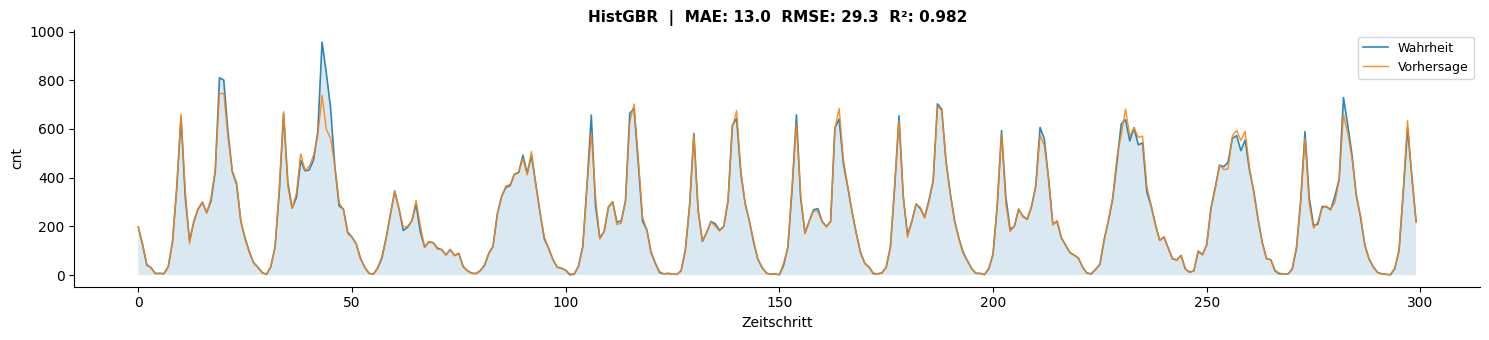

In [8]:
hgb = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=63,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(hgb, X_train, y_train, ts_cv)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
metrics_hgb = compute_metrics(y_test, y_pred_hgb)

result_hgb = {'name': 'HistGBR', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_hgb, **metrics_hgb}
all_results.append(result_hgb)
plot_predictions(result_hgb, y_test)

### Modellierung am Beispiel eines RandomForestRegressors

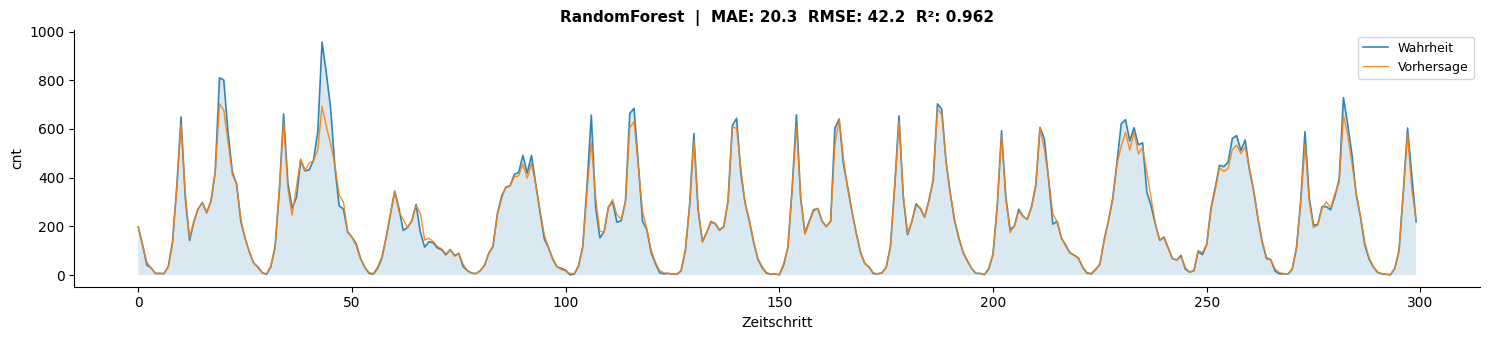

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cv_mae, cv_std = cross_validate_ts(rf, X_train, y_train, ts_cv)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_rf = compute_metrics(y_test, y_pred_rf)

result_rf = {'name': 'RandomForest', 'cv_mae': cv_mae, 'cv_std': cv_std,
             'y_pred': y_pred_rf, **metrics_rf}
all_results.append(result_rf)
plot_predictions(result_rf, y_test)

### Modellierung am Beispiel von CatBoost
#### Warum wird CatBoost verwendet? 

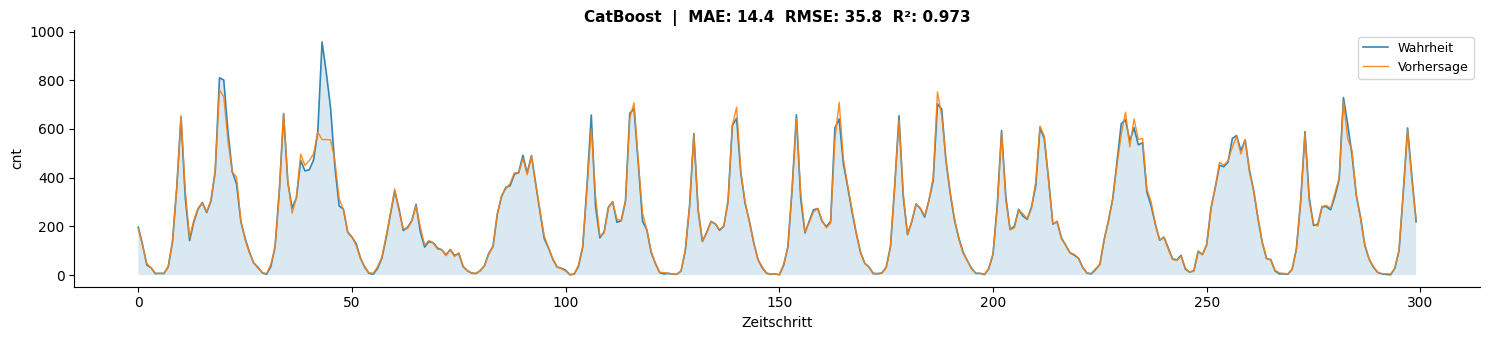

In [10]:
cat_model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.04,
    depth=7,
    min_data_in_leaf=10,
    subsample=0.8,
    random_seed=RANDOM_STATE,
    verbose=0
)

cv_mae, cv_std = cross_validate_ts(cat_model, X_train, y_train, ts_cv)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
metrics_cat = compute_metrics(y_test, y_pred_cat)

result_cat = {'name': 'CatBoost', 'cv_mae': cv_mae, 'cv_std': cv_std,
              'y_pred': y_pred_cat, **metrics_cat}
all_results.append(result_cat)
plot_predictions(result_cat, y_test)

### Modellierung am Beispiel von TabPFN
#### Was ist TabPFN?
[ToDo]


TabPFN Trainingssubset: 10000 Samples, 79 Features


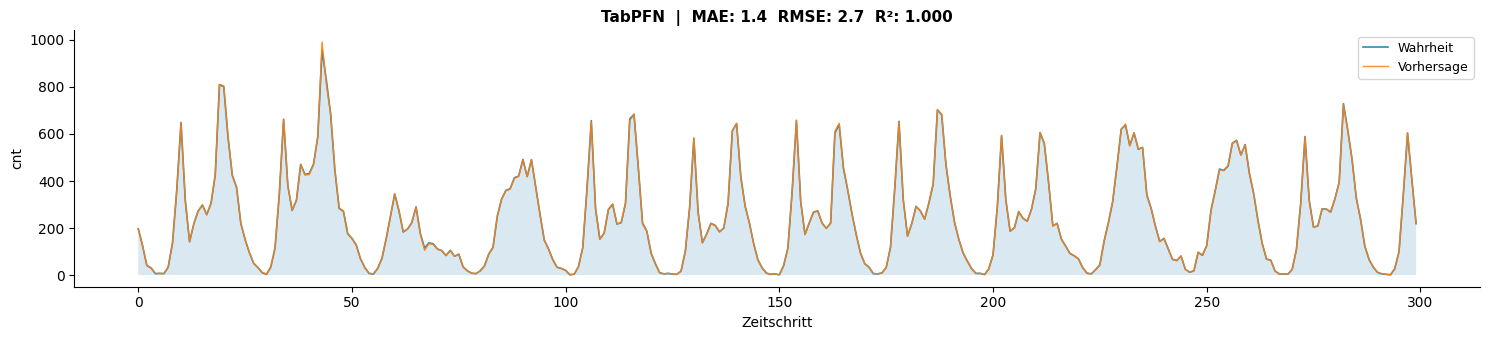

In [11]:
load_dotenv()

os.environ["TABPFN_TOKEN"] = os.getenv("TABPFN_TOKEN")


TABPFN_MAX_TRAIN = 10_000

if len(X_train) > TABPFN_MAX_TRAIN:
    X_train_tab = X_train.iloc[-TABPFN_MAX_TRAIN:]
    y_train_tab = y_train.iloc[-TABPFN_MAX_TRAIN:]
else:
    X_train_tab = X_train
    y_train_tab = y_train

print(f'TabPFN Trainingssubset: {len(X_train_tab)} Samples, {X_train_tab.shape[1]} Features')

tabpfn = TabPFNRegressor(
    n_estimators=8,
    device='cpu',
    ignore_pretraining_limits=True,
)

# Cross-Validation auf dem Subset
ts_cv_tab = TimeSeriesSplit(n_splits=3, test_size=500)
cv_mae_tab, cv_std_tab = cross_validate_ts(tabpfn, X_train_tab, y_train_tab, ts_cv_tab)

tabpfn.fit(X_train_tab, y_train_tab)
y_pred_tabpfn = tabpfn.predict(X_test)
metrics_tabpfn = compute_metrics(y_test, y_pred_tabpfn)

result_tabpfn = {
    'name':    'TabPFN',
    'cv_mae':  cv_mae_tab,
    'cv_std':  cv_std_tab,
    'y_pred':  y_pred_tabpfn,
    'note':    f'Subset (letzte {len(X_train_tab)} Trainings-Samples)',
    **metrics_tabpfn,
}
all_results.append(result_tabpfn)
plot_predictions(result_tabpfn, y_test)

## Vergleich 

In [12]:
rows = []
for r in all_results:
    if r['cv_mae'] is not None:
        cv_str = f"{r['cv_mae']:.1f} ± {r['cv_std']:.1f}"
    else:
        cv_str = f"n/a ({r.get('note', 'Subset')})"
    rows.append({
        'Methode':   r['name'],
        'CV-MAE':    cv_str,
        'Test MAE':  round(r['MAE'], 2),
        'Test RMSE': round(r['RMSE'], 2),
        'Test R²':   round(r['R2'], 4),
        'Hinweis':   r.get('note', '–'),
    })

results_df = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
results_df

,Methode,CV-MAE,Test MAE,Test RMSE,Test R²,Hinweis
0,TabPFN,0.9 ± 0.5,1.39,2.70,0.9998,Subset (letzte 10000 Trainings-Samples)
1,HistGBR,4.7 ± 1.9,12.95,29.35,0.9815,–
2,CatBoost,5.4 ± 1.8,14.42,35.77,0.9726,–
3,RandomForest,8.7 ± 3.2,20.35,42.21,0.9618,–


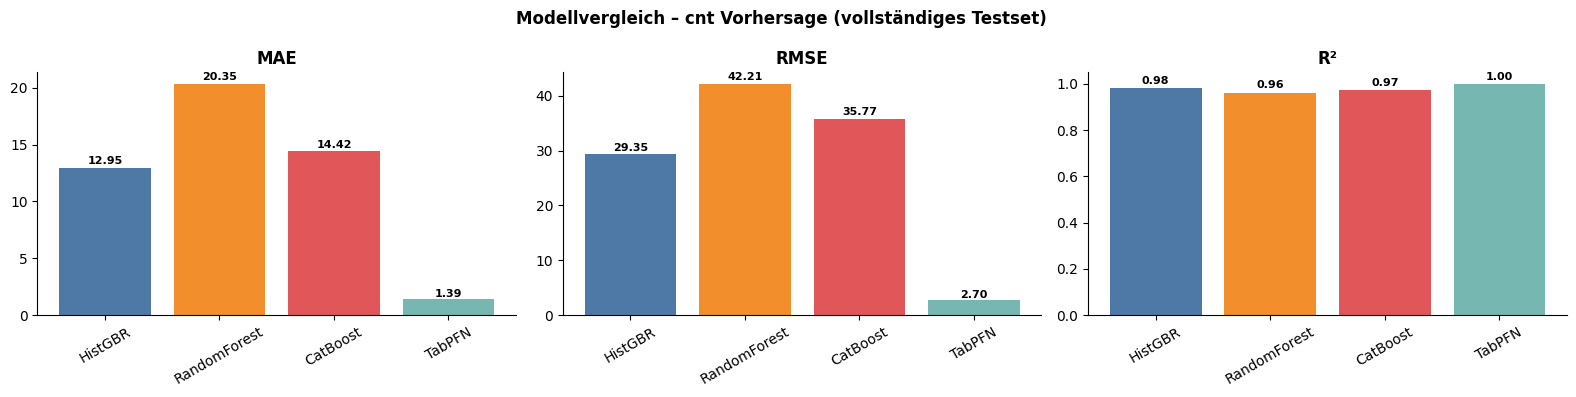

In [13]:
COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1','#ff9da7']

full_results = [r for r in all_results if len(r['y_pred']) >= 300]
names_full   = [r['name'] for r in full_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, label in zip(axes, ['MAE', 'RMSE', 'R2'], ['MAE', 'RMSE', 'R²']):
    vals = [r[metric] for r in full_results]
    bars = ax.bar(names_full, vals, color=COLORS[:len(names_full)], linewidth=0.5)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Modellvergleich – cnt Vorhersage (vollständiges Testset)', fontweight='bold')
plt.tight_layout()
plt.show()


## Hauptkomponentenanalyse / Primärkomponentenanalyse

## Feature Importance